# EDA

In [ ]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
DATA_DIR = Path("../data/ShapeNetCore")

Usamos metadatos para ver caracteristicas principales de la data

In [32]:
def explore_shapenet_structure():
    """Explora la estructura del dataset ShapeNet"""
    print("Estructura de datos:")
    
    # Verificar que existe el directorio
    if not DATA_DIR.exists():
        print(f"Directorio no encontrado: {DATA_DIR}")
        return pd.DataFrame()
    
    # Listar archivos ZIP disponibles
    zip_files = list(DATA_DIR.glob("*.zip"))
    print(f"Total de categorías disponibles: {len(zip_files)}")
    
    if not zip_files:
        print("No se encontraron archivos ZIP")
        return pd.DataFrame()
    
    categories_info = []
    for zip_file in zip_files:
        # Obtener información básica del ZIP
        try:
            file_size = zip_file.stat().st_size / (1024**2)  # MB
            category_id = zip_file.stem
            
            categories_info.append({
                'category_id': category_id,
                'filename': zip_file.name,
                'size_mb': round(file_size, 2)
            })
        except Exception as e:
            print(f"Error procesando {zip_file}: {e}")
    
    # Crear DataFrame con la info
    df_categories = pd.DataFrame(categories_info)
    df_categories = df_categories.sort_values('size_mb', ascending=False)

    
    return df_categories

In [33]:
df_categories = explore_shapenet_structure()
df_categories

Estructura de datos:
Total de categorías disponibles: 55


,category_id,filename,size_mb
16,02958343,02958343.zip,5422.08
0,02691156,02691156.zip,3203.42
18,03001627,03001627.zip,1874.23
49,04379243,04379243.zip,1589.76
53,04530566,04530566.zip,1251.94
47,04256520,04256520.zip,1232.10
44,04090263,04090263.zip,884.97
30,03636649,03636649.zip,710.79
11,02924116,02924116.zip,692.97
26,03467517,03467517.zip,553.55


In [52]:
def get_all_categories_stats():
    """Stats de todas las categorías con visualización"""
    
    zip_files = list(DATA_DIR.glob("*.zip"))
    stats = []
    
    for zip_file in zip_files:
        try:
            with zipfile.ZipFile(zip_file, 'r') as zf:
                files = zf.namelist()
                obj_files = [f for f in files if f.endswith('.obj')]
                
                # Contar modelos únicos
                model_ids = set()
                for f in obj_files:
                    parts = f.split('/')
                    if len(parts) >= 2:
                        model_ids.add(parts[1])
                
                stats.append({
                    'category_id': zip_file.stem,
                    'num_models': len(model_ids),
                    'size_mb': zip_file.stat().st_size / (1024**2),
                    'size_gb': zip_file.stat().st_size / (1024**3)
                })
                
        except Exception as e:
            print(f"Error en {zip_file.stem}: {e}")
    
    df_stats = pd.DataFrame(stats)
    df_stats = df_stats.sort_values('size_mb', ascending=False)
    
    # Calcular totales del dataset
    total_size_mb = df_stats['size_mb'].sum()
    total_size_gb = df_stats['size_gb'].sum()
    total_models = df_stats['num_models'].sum()

    print(f"Total de categorías: {len(df_stats)}")
    print(f"Total de modelos: {total_models:,}")
    print(f"Tamaño total: {total_size_gb:.2f} GB ({total_size_mb:.0f} MB)")
    print(f"Promedio por categoría: {total_size_mb/len(df_stats):.1f} MB")
    
    # Crear visualización con dos subgráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico: Top 15 categorías por tamaño
    top_15_size = df_stats.head(15)
    bars1 = ax1.bar(range(len(top_15_size)), top_15_size['size_mb'], 
                    color='steelblue', alpha=0.7, edgecolor='navy')
    ax1.set_xticks(range(len(top_15_size)))
    ax1.set_xticklabels(top_15_size['category_id'], rotation=45, ha='right', fontsize=9)
    ax1.set_title('Top 15 Categorías por Tamaño', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Tamaño (MB)')
    ax1.grid(axis='y', alpha=0.3)
    
    # Gráfico: Top 15 categorías por cantidad de modelos
    top_15_models = df_stats.nlargest(15, 'num_models')
    bars2 = ax2.bar(range(len(top_15_models)), top_15_models['num_models'], 
                    color='orange', alpha=0.7, edgecolor='darkorange')
    ax2.set_xticks(range(len(top_15_models)))
    ax2.set_xticklabels(top_15_models['category_id'], rotation=45, ha='right', fontsize=9)
    ax2.set_title('Top 15 Categorías por Número de Modelos', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Número de Modelos')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estadísticas adicionales
    print(f"Categoría más grande: {df_stats.iloc[0]['category_id']} ({df_stats.iloc[0]['size_mb']:.1f} MB)")
    print(f"Categoría más pequeña: {df_stats.iloc[-1]['category_id']} ({df_stats.iloc[-1]['size_mb']:.1f} MB)")
    print(f"Mediana de tamaños: {df_stats['size_mb'].median():.1f} MB")
    
    return df_stats

Total de categorías: 55
Total de modelos: 52,472
Tamaño total: 22.32 GB (22860 MB)
Promedio por categoría: 415.6 MB


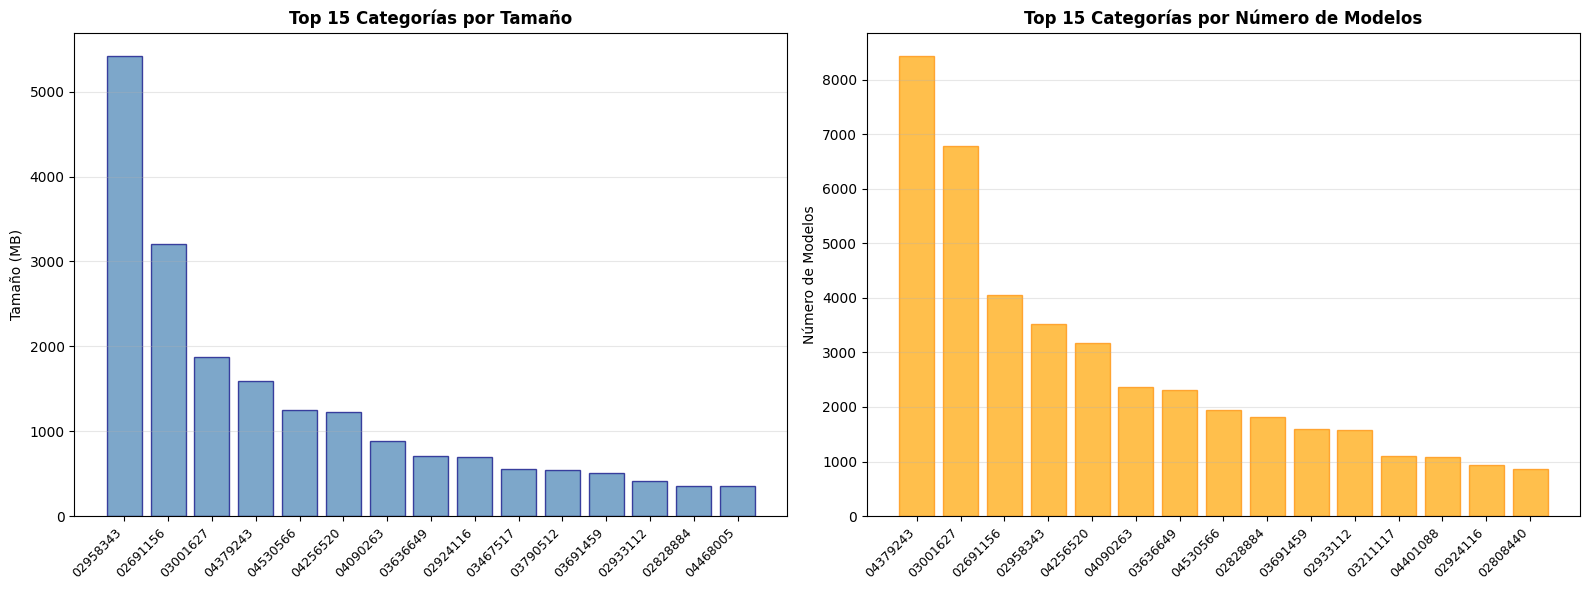

Categoría más grande: 02958343 (5422.1 MB)
Categoría más pequeña: 02843684 (4.2 MB)
Mediana de tamaños: 79.9 MB


In [53]:
categories_stats = get_all_categories_stats()

In [ ]:
def load_data_categories(target_categories=None):
    """Carga sillas, autos y aviones"""
    
    models_data = []
    
    for cat_id, cat_name in target_categories.items():
        zip_path = DATA_DIR / f"{cat_id}.zip"
        
        if not zip_path.exists():
            print(f"No se encontró {cat_name} ({cat_id})")
            continue
            
        print(f"Cargando {cat_name}...")
        
        with zipfile.ZipFile(zip_path, 'r') as zf:
            obj_files = [f for f in zf.namelist() if f.endswith('.obj')]
            
            # Tomar máximo 50 modelos por categoría para el análisis
            obj_files = obj_files[:100]
            
            for obj_file in obj_files:
                try:
                    # Extraer info del modelo
                    parts = obj_file.split('/')
                    model_id = parts[1] if len(parts) > 1 else "unknown"
                    
                    # Leer contenido OBJ
                    with zf.open(obj_file) as f:
                        content = f.read().decode('utf-8')
                    
                    # Contar vértices y caras
                    lines = content.split('\n')
                    vertices = [l for l in lines if l.startswith('v ')]
                    faces = [l for l in lines if l.startswith('f ')]
                    
                    models_data.append({
                        'category_id': cat_id,
                        'category_name': cat_name,
                        'model_id': model_id,
                        'obj_file': obj_file,
                        'num_vertices': len(vertices),
                        'num_faces': len(faces),
                        'obj_content': content
                    })
                    
                except Exception as e:
                    print(f"Error procesando {obj_file}: {e}")
        
        loaded_models = len([m for m in models_data if m['category_name'] == cat_name])
        print(f"{cat_name}: {loaded_models} modelos cargados")
    
    df_result = pd.DataFrame(models_data)
    return df_result

In [58]:
# IDs de las categorías que queremos
target_categories = {
    '03001627': 'chair',
    '02958343': 'car', 
    '02691156': 'airplane'
}
models_data = load_data_categories(target_categories)
models_data.head()

Cargando chair...
chair: 100 modelos cargados
Cargando car...
car: 100 modelos cargados
Cargando airplane...
airplane: 100 modelos cargados


,category_id,category_name,model_id,obj_file,num_vertices,num_faces,obj_content
0,03001627,chair,1006be65e7bc937e9141f9b58470d646,03001627/1006be65e7bc937e9141f9b58470d646/mode...,756,1910,# File produced by Open Asset Import Library (...
1,03001627,chair,1007e20d5e811b308351982a6e40cf41,03001627/1007e20d5e811b308351982a6e40cf41/mode...,2351,9276,# File produced by Open Asset Import Library (...
2,03001627,chair,100b18376b885f206ae9ad7e32c4139d,03001627/100b18376b885f206ae9ad7e32c4139d/mode...,327,1289,# File produced by Open Asset Import Library (...
3,03001627,chair,1013f70851210a618f2e765c4a8ed3d,03001627/1013f70851210a618f2e765c4a8ed3d/model...,720,2864,# File produced by Open Asset Import Library (...
4,03001627,chair,1015e71a0d21b127de03ab2a27ba7531,03001627/1015e71a0d21b127de03ab2a27ba7531/mode...,3354,12288,# File produced by Open Asset Import Library (...


In [72]:
def generate_plots(df_models):
    """Gráficos rápidos del EDA"""
    
    _, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Densidad geométrica (vértices/caras)
    categories = df_models['category_name'].unique()
    vertex_density = []
    categories_labels = []
    for cat in categories:
        cat_data = df_models[df_models['category_name'] == cat]
        density = cat_data['num_vertices'] / (cat_data['num_faces'] + 1)
        vertex_density.append(density)
        categories_labels.append(cat)
    
    ax1.boxplot(vertex_density, tick_labels=categories_labels)
    ax1.set_title('Densidad Geométrica (Vértices/Caras)')
    ax1.set_ylabel('Densidad')
    ax1.grid(True, alpha=0.3)
    
    # Distribución de vértices en nuestras 3 categorías
    ax2.boxplot([
        df_models[df_models['category_name']=='chair']['num_vertices'],
        df_models[df_models['category_name']=='car']['num_vertices'],
        df_models[df_models['category_name']=='airplane']['num_vertices']
    ], tick_labels=['Sillas', 'Autos', 'Aviones'])
    ax2.set_title('Distribución de Vértices por Categoría')
    ax2.set_ylabel('Número de Vértices')
    
    # Distribución de caras
    ax3.boxplot([
        df_models[df_models['category_name']=='chair']['num_faces'],
        df_models[df_models['category_name']=='car']['num_faces'],
        df_models[df_models['category_name']=='airplane']['num_faces']
    ], tick_labels=['Sillas', 'Autos', 'Aviones'])
    ax3.set_title('Distribución de Caras por Categoría')
    ax3.set_ylabel('Número de Caras')
    
    # Scatter vértices vs caras
    categories = df_models['category_name'].unique()
    colors = ['red', 'blue', 'green']
    
    for i, cat in enumerate(categories):
        cat_data = df_models[df_models['category_name'] == cat]
        ax4.scatter(cat_data['num_vertices'], cat_data['num_faces'], 
                   alpha=0.6, label=cat, color=colors[i])
    
    ax4.set_xlabel('Número de Vértices')
    ax4.set_ylabel('Número de Caras')
    ax4.set_title('Vértices vs Caras por Categoría')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

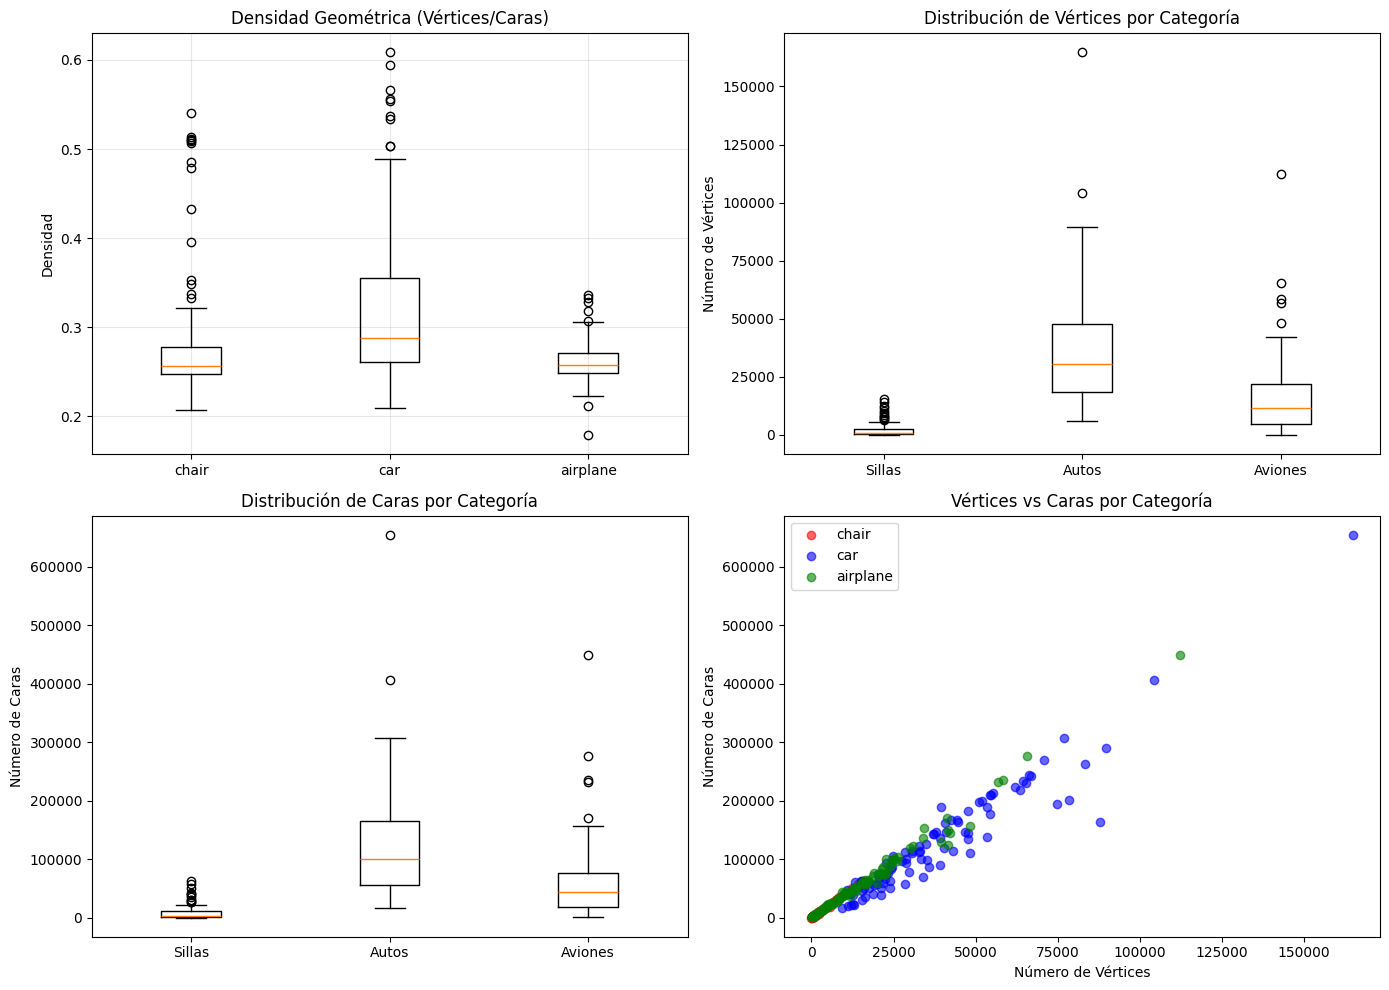

In [73]:
generate_plots(models_data)

In [74]:
def show_3d_sample(df_models, category='chair', model_idx=0):
    """Muestra un modelo 3D simple"""
    
    # Filtrar por categoría
    cat_models = df_models[df_models['category_name'] == category]
    
    if len(cat_models) == 0:
        print(f"No hay modelos de {category}")
        return
    
    # Obtener el modelo
    model = cat_models.iloc[model_idx]
    obj_content = model['obj_content']
    
    # Parsear solo vértices
    vertices = []
    for line in obj_content.split('\n'):
        if line.startswith('v '):
            coords = line.split()[1:4]
            vertices.append([float(x) for x in coords])
    
    if len(vertices) == 0:
        print("No se encontraron vértices")
        return
    
    # Crear gráfico 3D simple
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    vertices = np.array(vertices)
    
    # Plot con Y como eje vertical (intercambiar Y y Z)
    ax.scatter(vertices[:, 0], vertices[:, 2], vertices[:, 1], 
              s=20,           # Puntos grandes
              alpha=0.7,      # Transparencia
              color='blue')   # Un solo color
    
    ax.set_title(f'{category.title()} - Modelo {model_idx}')
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y (up)')  # Y es ahora el eje hacia arriba
    
    plt.show()
    
    print(f"Modelo: {model['model_id']}")
    print(f"Vértices: {len(vertices)}")

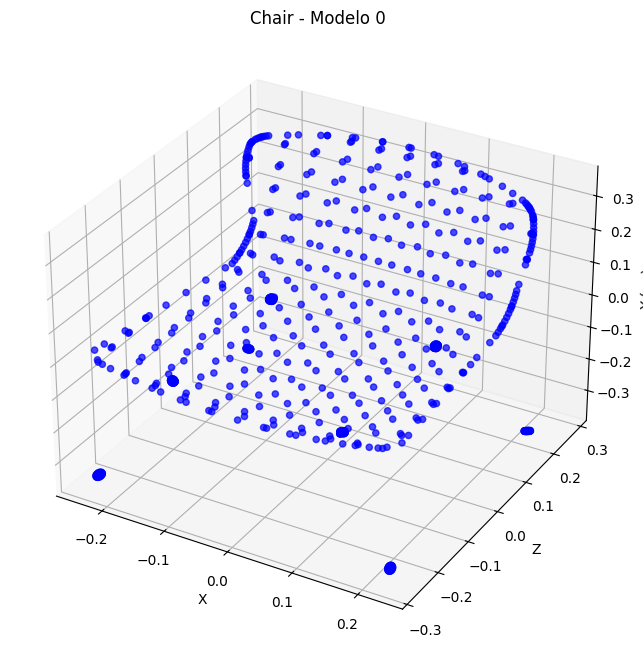

Modelo: 1006be65e7bc937e9141f9b58470d646
Vértices: 756


In [65]:
show_3d_sample(models_data, category='chair', model_idx=0)

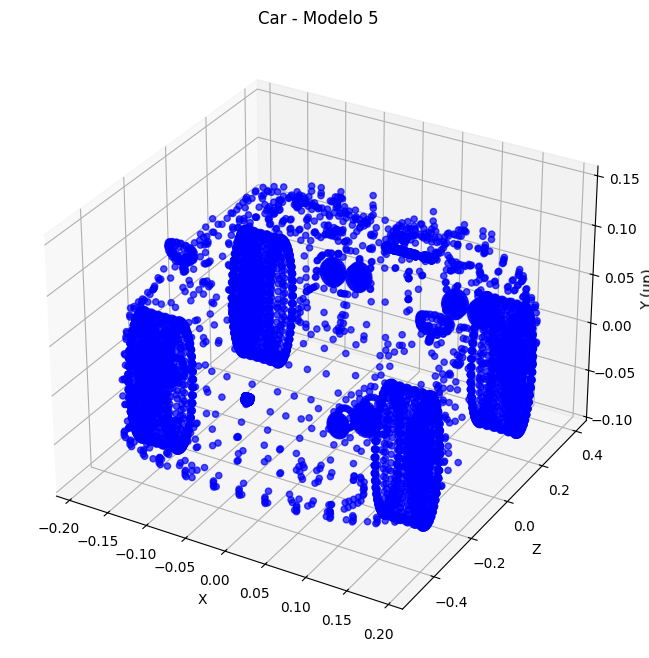

Modelo: 10716a366de708b8fac96522b26f7fd
Vértices: 17628


In [20]:
show_3d_sample(models_data, category='car', model_idx=5)

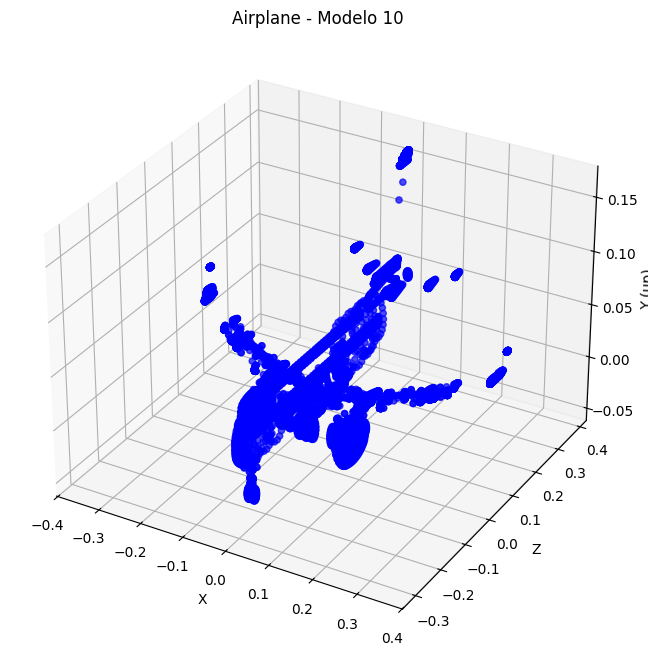

Modelo: 10cfc2090a2ade124c3a35cee92bb95b
Vértices: 22758


In [19]:
show_3d_sample(models_data, category='airplane', model_idx=10)

In [92]:
def run_symmetry_analysis(df_models):
    """ Analiza simetría simple de modelos 3D """

    def nearest_distances(A, B):
        if A.shape[0] == 0 or B.shape[0] == 0:
            return np.array([])
        tree = cKDTree(B)
        d, _ = tree.query(A, k=1)
        return d

    def reflection_score(V, axis_idx, eps):
        if V.shape[0] == 0:
            return 0.0
        R = V.copy()
        R[:, axis_idx] *= -1
        d = nearest_distances(R, V)
        return float((d <= eps).mean())

    rows = []
    for _, row in df_models.iterrows():
        verts = []
        for line in row['obj_content'].splitlines():
            if line.startswith('v '):
                parts = line.split()
                verts.append([float(parts[1]), float(parts[2]), float(parts[3])])
        verts = np.array(verts, dtype=np.float32)

        if len(verts) == 0:
            continue

        centroid = verts.mean(axis=0, keepdims=True)
        Vc = verts - centroid

        bbox = Vc.max(axis=0) - Vc.min(axis=0)
        diag = np.linalg.norm(bbox)
        eps = 0.01 * diag

        sx = reflection_score(Vc, 0, eps)
        sy = reflection_score(Vc, 1, eps)
        sz = reflection_score(Vc, 2, eps)

        scores = [sx, sy, sz]
        best_axis = ['x', 'y', 'z'][np.argmax(scores)]

        rows.append({
            'model_id': row['model_id'],
            'category_name': row['category_name'],
            'symmetry_x': sx,
            'symmetry_y': sy,
            'symmetry_z': sz,
            'best_axis': best_axis,
            'best_score': max(scores),
            'bbox_x': bbox[0],
            'bbox_y': bbox[1],
            'bbox_z': bbox[2]
        })

    df_sym = pd.DataFrame(rows)

    _ = sorted(df_sym['category_name'].dropna().unique())
    _, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Barras medias
    means = df_sym.groupby("category_name")[["symmetry_x","symmetry_y","symmetry_z"]].mean()
    means.plot.bar(ax=axes[0,0])
    axes[0,0].set_title("Simetría promedio por eje")
    axes[0,0].grid(alpha=0.3)

    # Boxplot best_score
    df_sym.boxplot(column="best_score", by="category_name", ax=axes[0,1])
    axes[0,1].set_title("Distribución best score")
    axes[0,1].grid(alpha=0.3)

    # Scatter bbox_x vs best_score (ejemplo simple)
    axes[1,0].scatter(df_sym["bbox_x"], df_sym["best_score"], alpha=0.6)
    axes[1,0].set_xlabel("BBox X")
    axes[1,0].set_ylabel("Best score")
    axes[1,0].set_title("Relación tamaño vs simetría")
    axes[1,0].grid(alpha=0.3)

    # Correlaciones
    corr = df_sym[["symmetry_x","symmetry_y","symmetry_z","best_score"]].corr()
    im = axes[1,1].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1,1].set_xticks(range(len(corr.columns)))
    axes[1,1].set_yticks(range(len(corr.columns)))
    axes[1,1].set_xticklabels(corr.columns, rotation=45)
    axes[1,1].set_yticklabels(corr.columns)
    axes[1,1].set_title("Correlaciones")
    plt.colorbar(im, ax=axes[1,1])

    plt.suptitle("Análisis de Simetría")
    plt.tight_layout()
    plt.show()

    return df_sym

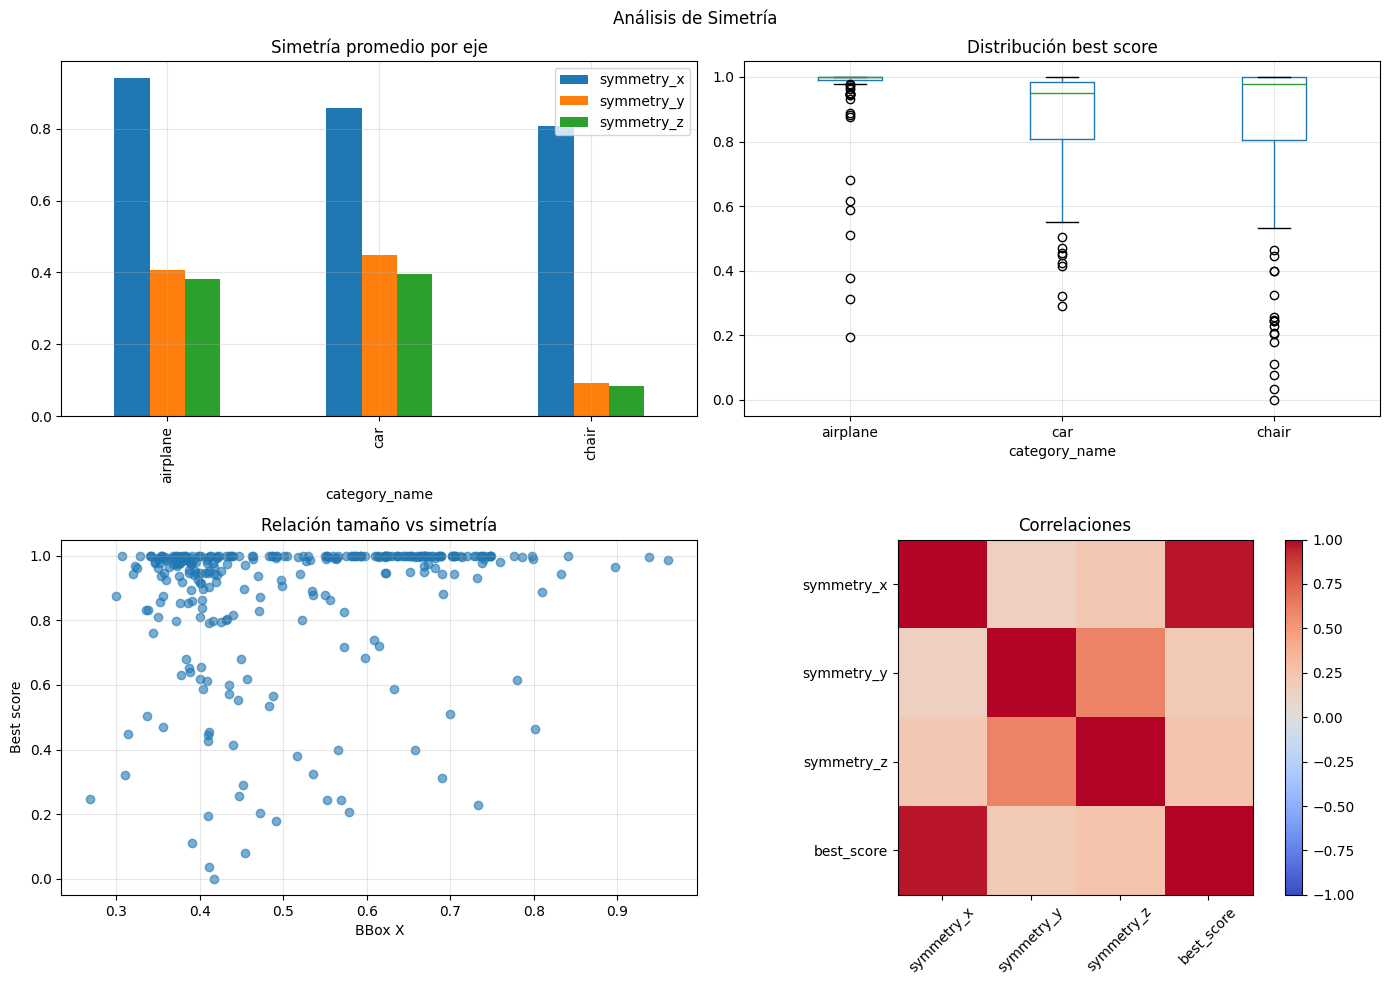

,model_id,category_name,symmetry_x,symmetry_y,symmetry_z,best_axis,best_score,bbox_x,bbox_y,bbox_z
0,1006be65e7bc937e9141f9b58470d646,chair,0.871693,0.026455,0.009259,x,0.871693,0.472459,0.684696,0.554954
1,1007e20d5e811b308351982a6e40cf41,chair,0.202892,0.060825,0.050191,x,0.202892,0.471667,0.683442,0.557169
2,100b18376b885f206ae9ad7e32c4139d,chair,0.464832,0.162080,0.000000,x,0.464832,0.801089,0.490250,0.343384
3,1013f70851210a618f2e765c4a8ed3d,chair,0.994444,0.183333,0.113889,x,0.994444,0.491386,0.531801,0.689730
4,1015e71a0d21b127de03ab2a27ba7531,chair,1.000000,0.065295,0.128801,x,1.000000,0.423605,0.757158,0.497262


In [93]:
df_sym = run_symmetry_analysis(models_data)
df_sym.head()